In [ ]:
import pandas as pd
from modules.predictor.data.utils import data_preprocessing

# df_experts1 = pd.read_csv('../../../data/raw/data_experts1.csv')
df_experts1 = data_preprocessing('../../../data/raw/data_experts1.csv', 'expert')
df_experts1

In [104]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
from pymatgen.vis.structure_chemview import quick_view
from modules.core.features.symmetries import translate_point_group_to_symmetry_description
from modules.core.features.utils import get_pymatgen_molecule_from_smiles
from pymatgen.symmetry.analyzer import PointGroupAnalyzer
import pandas as pd
import numpy as np

from pymatgen.vis.structure_vtk import StructureVis

from rdkit import Chem
from rdkit.Chem import AllChem, Mol, MolToXYZFile, rdDepictor, rdDistGeom
import matplotlib.pyplot as plt

from modules.core.features.preprocessing import canon_smiles

df = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
df = df[['smiles_old', 'wielkosc_pora teoretyczna']].groupby('smiles_old').aggregate('mean').reset_index()
#pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
df_smiles = pd.read_excel('../../../data/raw/data_battery_materials.xlsx', na_values=['not given'])
df_smiles = df_smiles[df_smiles['dataset'] == 'expert1']
df_smiles = df_smiles[['smiles', 'SMILES to be used']]
df_smiles = df_smiles.rename(columns={'SMILES to be used': 'smiles_new', 'smiles': 'smiles_old'})
df = df.merge(df_smiles, on='smiles_old', how='inner')
df['canon_smiles'] = [canon_smiles(s) for s in df['smiles_new'].tolist()]
df = df[['canon_smiles', 'wielkosc_pora teoretyczna']]
pore_sizes = df['wielkosc_pora teoretyczna'].tolist()
df

,canon_smiles,wielkosc_pora teoretyczna
0,N#Cc1ccc(/C=C/C(/C=C/c2ccc(C#N)cc2)/C=C/c2ccc(...,NaN
1,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,3.60
2,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,3.60
3,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,2.90
4,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,3.20
5,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,2.90
6,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,2.40
7,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,1.30
8,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,0.90
9,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,1.00


Point group: Cs
Symmetry description: mirror plane


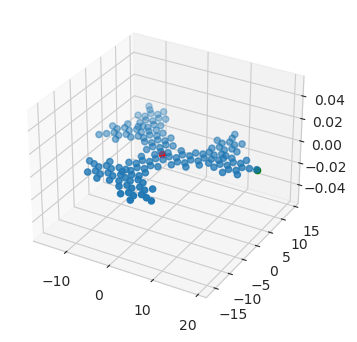

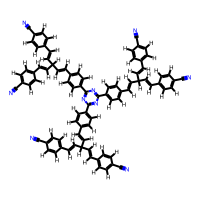

Pore size estimated: 3.666397318747376, pore size true: nan
--------------------------------------------------------
Point group: C1
Symmetry description: no symmetry, chiral


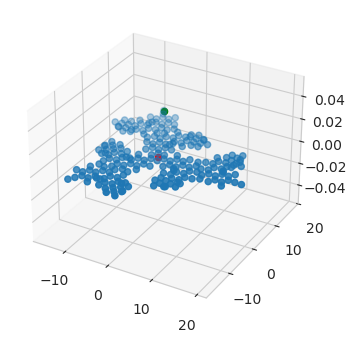

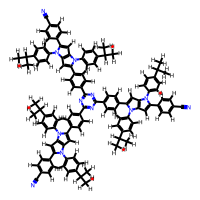

Pore size estimated: 3.6680687789354565, pore size true: 3.6
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


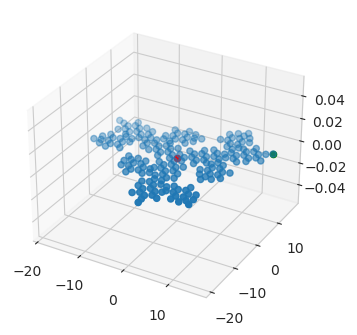

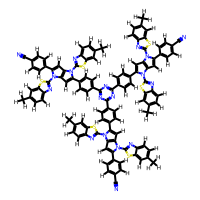

Pore size estimated: 3.660493455453387, pore size true: 3.6
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


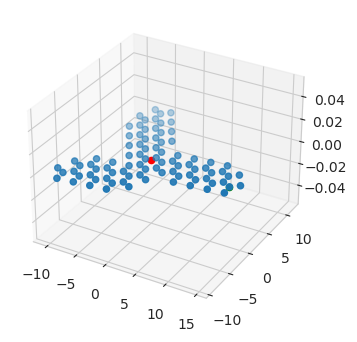

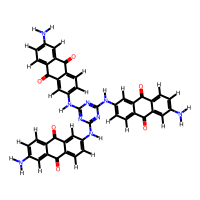

Pore size estimated: 2.5362412279134166, pore size true: 2.9
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


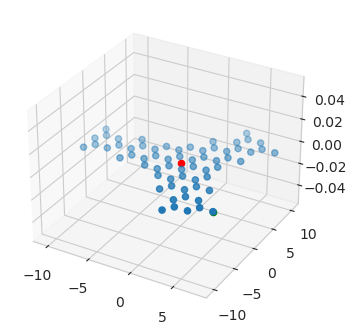

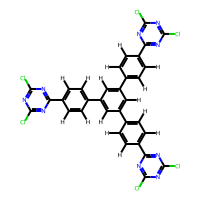

Pore size estimated: 2.0184150823989575, pore size true: 3.2
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


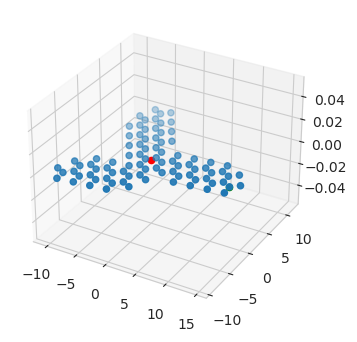

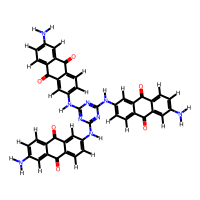

Pore size estimated: 2.5362412279134166, pore size true: 2.9
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


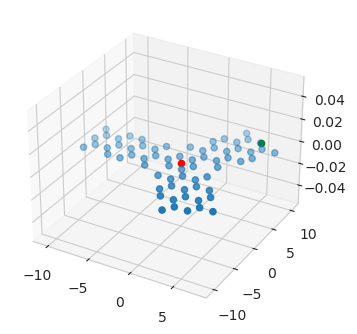

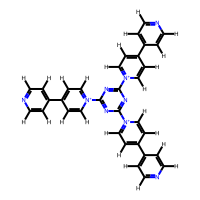

Pore size estimated: 1.9593266739736612, pore size true: 2.4
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


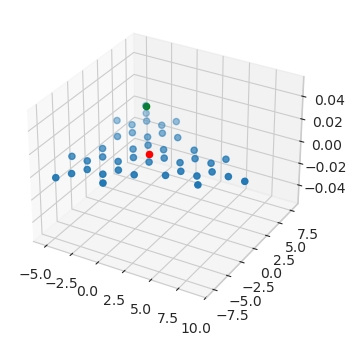

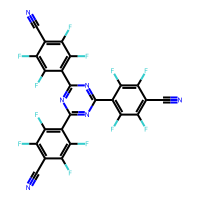

Pore size estimated: 1.6794228634059956, pore size true: 1.3
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


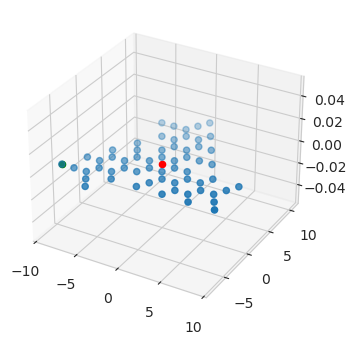

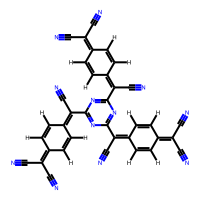

Pore size estimated: 1.9392304845413268, pore size true: 0.9
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


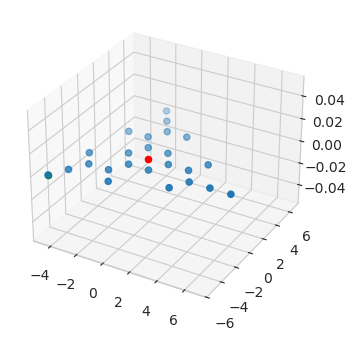

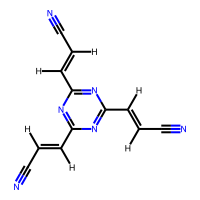

Pore size estimated: 1.282680399232909, pore size true: 1.0
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


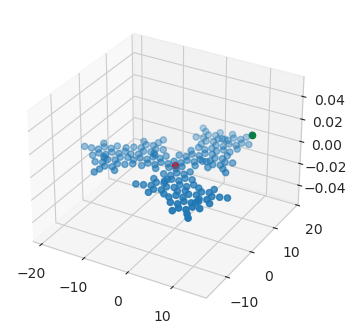

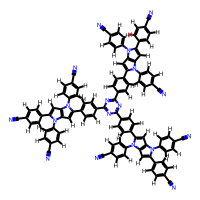

Pore size estimated: 3.6609106518494485, pore size true: 3.6
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


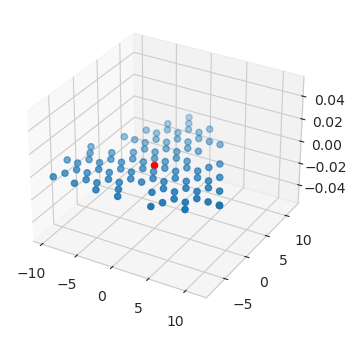

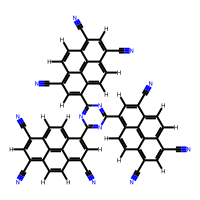

Pore size estimated: 2.221667621773186, pore size true: 1.1
--------------------------------------------------------
Point group: C1
Symmetry description: no symmetry, chiral


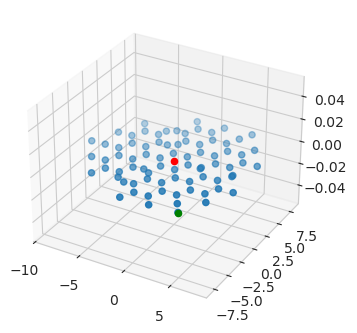

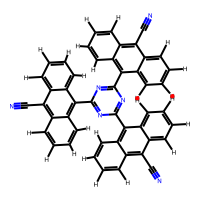

Pore size estimated: 1.6795803274335541, pore size true: 1.3
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


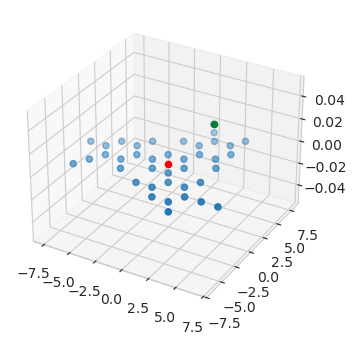

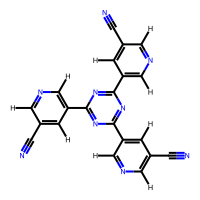

Pore size estimated: 1.4544228634059955, pore size true: 0.6
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


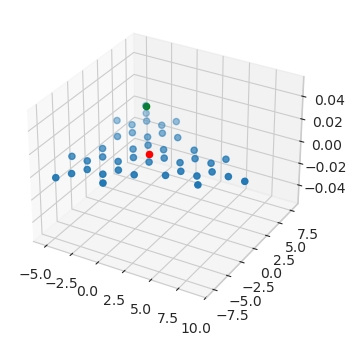

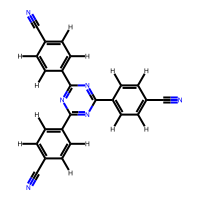

Pore size estimated: 1.6794228634059956, pore size true: 1.29
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


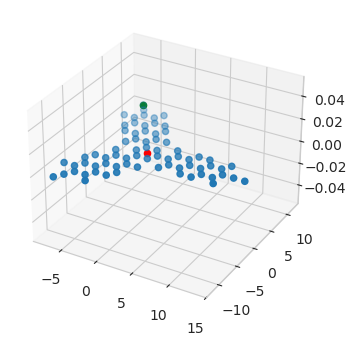

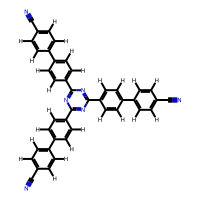

Pore size estimated: 2.5191342951089934, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


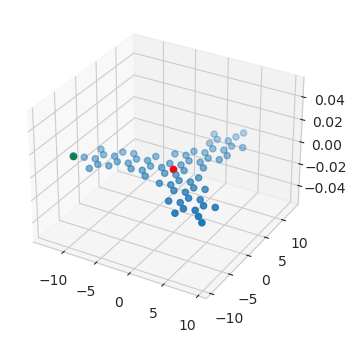

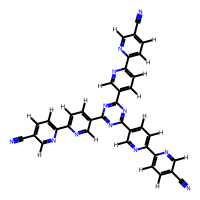

Pore size estimated: 2.531867851262463, pore size true: 2.0
--------------------------------------------------------
Point group: C3h
Symmetry description: propeller


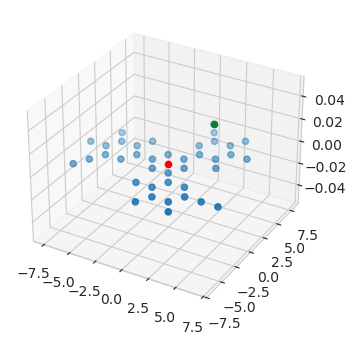

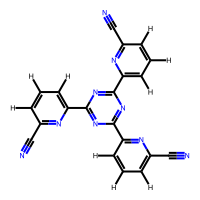

Pore size estimated: 1.4544228634059955, pore size true: 0.6
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


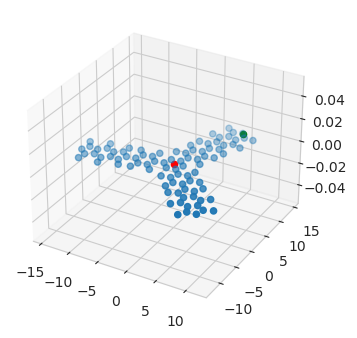

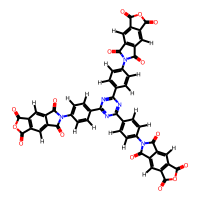

Pore size estimated: 2.745782023750387, pore size true: 4.2
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


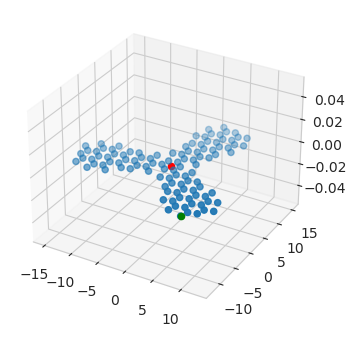

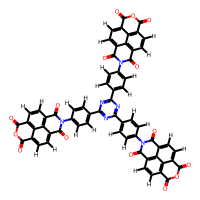

Pore size estimated: 2.8407134268657206, pore size true: 4.2
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


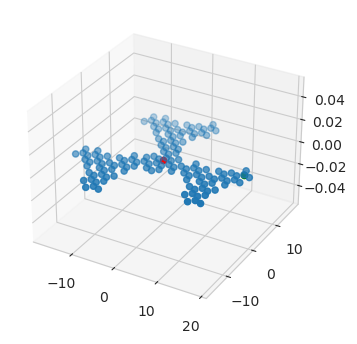

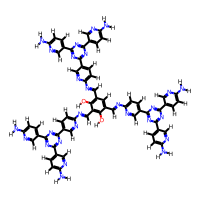

Pore size estimated: 3.2343835119579025, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


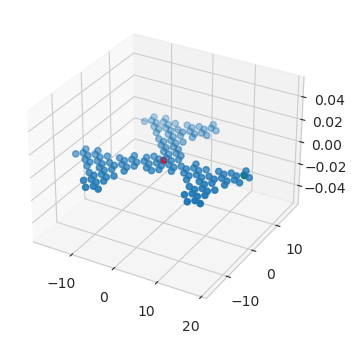

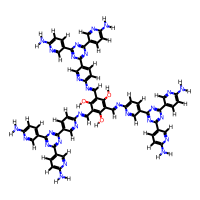

Pore size estimated: 3.2306166104888923, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


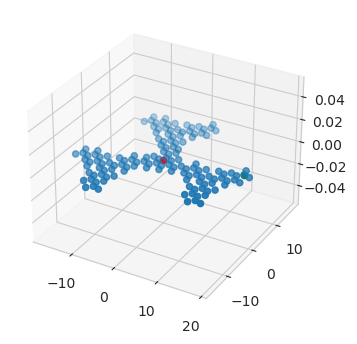

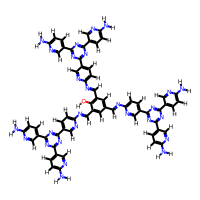

Pore size estimated: 3.233632720398923, pore size true: 2.0
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


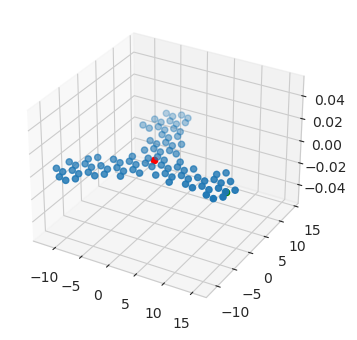

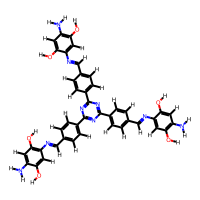

Pore size estimated: 2.7361356411724795, pore size true: 3.4
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


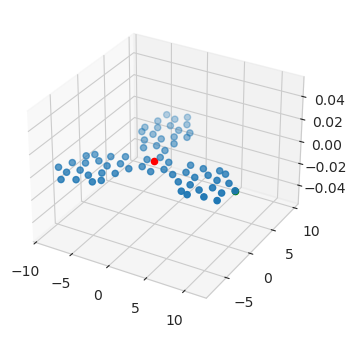

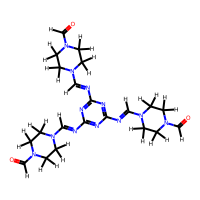

Pore size estimated: 2.1267169542553988, pore size true: 2.3
--------------------------------------------------------
Point group: Cs
Symmetry description: mirror plane


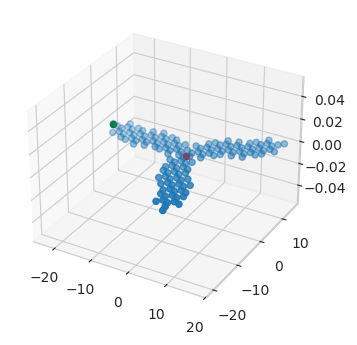

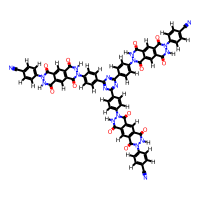

Pore size estimated: 4.357279200174041, pore size true: 3.8
--------------------------------------------------------
Point group: D3h
Symmetry description: trigonal planar or trigonal bipyramidal


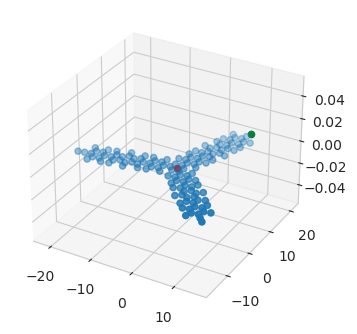

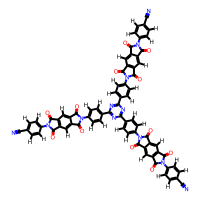

Pore size estimated: 4.145301076588716, pore size true: 3.9
--------------------------------------------------------


In [107]:
smiles = df['canon_smiles'].tolist()

# smiles = df.drop_duplicates(subset=['smiles'])['smiles'].tolist()
# smiles = [canon_smiles(s) for s in smiles]
#
for s, p in zip(smiles, pore_sizes):
    TRANSLATION_TABLE_PATH = "../../../data/symmetries/symmetry_translation.csv"

    molecule = get_pymatgen_molecule_from_smiles(s, save_file=True)
    pga = PointGroupAnalyzer(molecule)
    symmetry_operations = pga.get_symmetry_operations()
    rotational_symmetry = pga.get_rotational_symmetry_number()
    point_group = pga.get_pointgroup()
    equivalent_atoms = pga.get_equivalent_atoms()

    # print(f"Symmetry operations: {symmetry_operations}")
    # print(f"Rotational symmetry number: {rotational_symmetry}")
    print(f"Point group: {point_group}")
    #print(pga.inversion_op)
    #print(f"Equivalent atoms: {equivalent_atoms}")

    symmetry_description = translate_point_group_to_symmetry_description(str(point_group), TRANSLATION_TABLE_PATH)
    print(f"Symmetry description: {symmetry_description}")
    #structure = molecule.get_boxed_structure(23, 23, 23)

    #view(AseAtomsAdaptor().get_atoms(structure))
    # coordinates = []
    # species = []
    #
    # for s in structure:
    #         coordinates.append(s.coords) #cartesian coordinates
    #         species.append(s.specie)
    #
    # print(coordinates)
    # print(species)
    molecule = Chem.MolFromSmiles(s, sanitize=True)
    molecule = Chem.AddHs(molecule)
    rdDepictor.Compute2DCoords(molecule, sampleSeed=42)

    nitrogen_indices = [
            bond.GetEndAtomIdx() if bond.GetBeginAtom().GetSymbol() == "C" and bond.GetEndAtom().GetSymbol() == "N" else bond.GetBeginAtomIdx()
            for bond in molecule.GetBonds()
            if bond.GetBondType() == Chem.BondType.TRIPLE and {"C", "N"} == {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()}
        ]
    if len(nitrogen_indices) == 0:
        nitrogen_indices = [atom.GetIdx() for atom in molecule.GetAtoms() if atom.GetSymbol() != 'H']
        # nitrogen_indices = list(range(0, molecule.GetNumAtoms()))
        # nitrogen_indices = [
        #     bond.GetEndAtomIdx() if bond.GetBeginAtom().GetSymbol() != "H" and bond.GetEndAtom().GetSymbol() != "!" else bond.GetBeginAtomIdx()
        #     for bond in molecule.GetBonds()
        #     if bond.GetBondType() == Chem.BondType.TRIPLE and {"C", "N"} == {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()}
        # ]

    conf = molecule.GetConformer(0)
    coords = conf.GetPositions()

    max_distance = 0
    atom_pos = None

    for j in nitrogen_indices: #range(0, molecule.GetNumAtoms()):
        pos_j = np.array(conf.GetAtomPosition(j))

        # Calculate the distance between the two points
        distance = np.linalg.norm(np.array([0, 0, 0]) - pos_j)

        if distance > max_distance:
            max_distance = distance
            atom_pos = pos_j

    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2])
    ax.scatter(0, 0, 0, c='red')
    ax.scatter(atom_pos[0], atom_pos[1], atom_pos[2], c='green')
    plt.show()
    display(Chem.Draw.MolsToImage([molecule]))

    perimeter = max_distance * 6

    pore_diameter = (max_distance * (3 ** 0.5) + max_distance * 2) / 2#perimeter / np.pi

    pore_diameter_nm = pore_diameter / 10  # Convert to nanometers
    print(f'Pore size estimated: {pore_diameter_nm}, pore size true: {p}')

    print('--------------------------------------------------------')

In [ ]:
import pandas as pd
import os
maccs_path = '../../../data/fingerprints_maccs/'
data_paths = ['data_experts1', 'data_zhu', 'data_saad', 'data_experts2', 'data_experts3']
dfs = []
for d in data_paths:
    df = pd.read_csv(os.path.join(maccs_path, f'{d}.csv'))
    df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
    df = df.sort_values(by="smiles").reset_index(drop=True)
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
df_all = df_all.loc[:, ~df_all.eq(df_all.iloc[0]).all()]
df_all.to_csv('maccs_merged.csv')


In [8]:
import pandas as pd
import os
dir_path = '../../../data/'
data_paths = ['data_experts1', 'data_zhu', 'data_saad', 'data_experts2', 'data_experts3']
features = ['fingerprints_maccs', 'fingerprints_estate']
dfs = []

for d in data_paths:
    df_read = [pd.read_csv(os.path.join(dir_path, f, f'{d}.csv')) for f in features]
    print([d.columns[0] for d in df_read])
    df = df_read[0]
    for data in df_read[1:]:
        data = data.drop(columns=["capacity_max"])
        df = pd.merge(df, data, on="smiles", how="inner")
    df.columns = df.columns.str.replace(r"[\[\]>]", "", regex=True)
    df = df.loc[:, ~df.columns.duplicated()].sort_values(by="smiles").reset_index(drop=True)
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True).sort_values(by="smiles").reset_index(drop=True)
df_all = df_all.loc[:, ~df_all.eq(df_all.iloc[0]).all()]
df_all.to_csv('maccs_estate_merged.csv', index=False)

['maccsfingerprint0', 'estatefingerprint0']
['maccsfingerprint0', 'estatefingerprint0']
['maccsfingerprint0', 'estatefingerprint0']
['maccsfingerprint0', 'estatefingerprint0']
['maccsfingerprint0', 'estatefingerprint0']


In [ ]:
df_all

In [76]:
import pandas as pd
df_smiles = pd.read_excel('../../../data/raw/data_battery_materials.xlsx', na_values=['not given'])
df_smiles = df_smiles[df_smiles['dataset'] == 'expert1']
#df_smiles = df_smiles[df_smiles['capacity_max'] != 'not given']
#df_smiles['capacity_max']
#df_smiles = df_smiles[~df_smiles['capacity_max'].isna()]
df_smiles = df_smiles[['smiles', 'SMILES to be used', 'capacity_max']]
df_smiles = df_smiles.rename(columns={'SMILES to be used': 'smiles_new_new'})
df_smiles['capacity_max'] = df_smiles['capacity_max'].astype(float)

In [77]:
from modules.core.features.preprocessing import preprocess_target, canon_smiles

df_corrected = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')
column_names_mapping = {
        "zwiazek": "substance",
        "smiles": "smiles",
        "masa_molowa": "molecular_weight",
        "liczba_pierscieni": "number_of_rings",
        "srednia_liczba_N_w_pierscieniu": "average_number_of_N_in_ring",
        "liczba_substratu_w_porze": "number_of_substrates_in_pore",
        "energia Gibbsa": "Gibbs_energy",
        "odleglosc_miedzy_najdalszymi_grupami": "distance_between_furthest_groups",
        "kondensacja": "condensation",
        "piroliza": "pyrolysis",
        "temperatura": "temperature",
        "N_perc_triaz": "N_perc_triaz",
        "wielkosc_pora teoretyczna": "PS",  # Pore Size
        "BET": "SSA",  # BET surface area
        "objetosc": "PV",  # Pore Volume
        "objetosc_mikroporow": "micropore_volume",
        "pojemnosc_3_H2SO4_CV": "capacity_H2SO4_CV",
        "pojemnosc_3_H2SO4_GCD": "capacity_H2SO4_GCD",
        "pojemnosc_3_NaOH_CV": "capacity_NaOH_CV",
        "pojemnosc_3_NaOH_GCD": "capacity_NaOH_GCD",
        "SSSS": "SSSSS",
    }

df_experts = df_corrected.rename(columns=column_names_mapping)
df_experts[["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]] = df_experts[
    ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
].replace("~", "", regex=True)
df_experts[["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]] = df_experts[
    ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
].astype(float)

# Calculate mean capacity
df_experts["capacity_H2SO4_mean"] = df_experts.loc[:, ["capacity_H2SO4_CV", "capacity_H2SO4_GCD"]].mean(axis=1)
df_experts["capacity_NaOH_mean"] = df_experts.loc[:, ["capacity_NaOH_CV", "capacity_NaOH_GCD"]].mean(axis=1)
df_experts["capacity_mean"] = df_experts.loc[:, ["capacity_H2SO4_mean", "capacity_NaOH_mean"]].mean(axis=1)

targets = ["capacity_H2SO4_CV", "capacity_H2SO4_GCD", "capacity_NaOH_CV", "capacity_NaOH_GCD"]
df_experts["capacity_max"] = preprocess_target(df_experts, targets=targets)

#df_experts = df_experts.loc[~df_experts["capacity_max"].isna()].reset_index(drop=True)

df_experts["smiles"] = df_experts["smiles"].apply(canon_smiles)
#df_experts['smiles_old'] = df_experts['smiles_old'].apply(canon_smiles)

df_experts.dropna(subset=["smiles", 'smiles_old'], inplace=True)
df_experts = df_experts.rename(columns={'smiles': 'smiles_new', 'smiles_old': 'smiles'})

df_corrected = df_experts[['smiles_new', 'smiles', 'capacity_max']]
df_corrected = df_corrected.groupby(["smiles", "smiles_new"]).max("capacity_max").reset_index()
df_corrected['capacity_max'] = df_corrected['capacity_max'].astype(float)
df_corrected

,smiles,smiles_new,capacity_max
0,C#CC(C=C1)=CC=C1C#N,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0
1,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0
2,CC1=CC2=C(C=C1)N=C(N3C(C4=CC=C(C#N)C=C4)=CC5=C...,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0
3,ClC1=NC(/N=C2=CC3=C(C(C(C=C(N)C=C4)=C4C3=O)=O)...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0
4,ClC1=NC(C(C=C2)=CC=C2C3=CC(C4=CC=CC=C4)=CC(C5=...,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0
5,ClC1=NC(Cl)=NC(NC2=CC3=C(C(C(C=C(N)C=C4)=C4C3=...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,NaN
6,ClC1=NC([N+](C=C2)=CC=C2C3=CC=NC=C3)=NC(Cl)=N1,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0
7,FC1=C(F)C(C#N)=C(F)C(F)=C1C#N,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0
8,N#C/C(C#N)=C(C=C/1)/C=CC1=C(C#N)/C#N,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0
9,N#C/C=C/C#N,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0


In [78]:
# Ensure both 'smiles' columns are strings and strip any leading/trailing spaces
df_corrected['smiles'] = df_corrected['smiles'].astype(str).str.strip()
df_smiles['smiles'] = df_smiles['smiles'].astype(str).str.strip()

# Check the data types of the 'smiles' columns
print(df_corrected['smiles'].dtype)
print(df_smiles['smiles'].dtype)

# Merge the dataframes
df_merged = df_corrected.merge(df_smiles, on='smiles', how='left')

object
object


In [79]:
df_merged

,smiles,smiles_new,capacity_max_x,smiles_new_new,capacity_max_y
0,C#CC(C=C1)=CC=C1C#N,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0,N#Cc%10ccc(/C=C/C(/C=C/c1ccc(C#N)cc1)/C=C/c9cc...,628.0
1,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,CC(C)c%19ccc(n2c(c1ccc(C#N)cc1)cc%17c2cc(c%16c...,255.0
2,CC1=CC2=C(C=C1)N=C(N3C(C4=CC=C(C#N)C=C4)=CC5=C...,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,Cc%25ccc%24nc(n2c(c1ccc(C#N)cc1)cc%21c2cc(c%20...,269.0
3,ClC1=NC(/N=C2=CC3=C(C(C(C=C(N)C=C4)=C4C3=O)=O)...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,NC1=CC(C(C(C=C2)=C3C=C2NC4=NC(NC5=CC6=C(C=C5)C...,468.0
4,ClC1=NC(C(C=C2)=CC=C2C3=CC(C4=CC=CC=C4)=CC(C5=...,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...,228.0
5,ClC1=NC(Cl)=NC(NC2=CC3=C(C(C(C=C(N)C=C4)=C4C3=...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,NaN,NC1=CC(C(C(C=C2)=C3C=C2NC4=NC(NC5=CC6=C(C=C5)C...,NaN
6,ClC1=NC([N+](C=C2)=CC=C2C3=CC=NC=C3)=NC(Cl)=N1,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,C1([N+]2=CC=C(C3=CC=NC=C3)C=C2)=NC([N+]4=CC=C(...,196.0
7,FC1=C(F)C(C#N)=C(F)C(F)=C1C#N,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,N#Cc4c(F)c(F)c(c3nc(c1c(F)c(F)c(C#N)c(F)c1F)nc...,379.0
8,N#C/C(C#N)=C(C=C/1)/C=CC1=C(C#N)/C#N,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#...,383.0
9,N#C/C=C/C#N,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0


In [80]:
df_merged = df_merged.drop_duplicates(subset=['smiles_new'])
df_merged

,smiles,smiles_new,capacity_max_x,smiles_new_new,capacity_max_y
0,C#CC(C=C1)=CC=C1C#N,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0,N#Cc%10ccc(/C=C/C(/C=C/c1ccc(C#N)cc1)/C=C/c9cc...,628.0
1,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,CC(C)c%19ccc(n2c(c1ccc(C#N)cc1)cc%17c2cc(c%16c...,255.0
2,CC1=CC2=C(C=C1)N=C(N3C(C4=CC=C(C#N)C=C4)=CC5=C...,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,Cc%25ccc%24nc(n2c(c1ccc(C#N)cc1)cc%21c2cc(c%20...,269.0
3,ClC1=NC(/N=C2=CC3=C(C(C(C=C(N)C=C4)=C4C3=O)=O)...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,NC1=CC(C(C(C=C2)=C3C=C2NC4=NC(NC5=CC6=C(C=C5)C...,468.0
4,ClC1=NC(C(C=C2)=CC=C2C3=CC(C4=CC=CC=C4)=CC(C5=...,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...,228.0
6,ClC1=NC([N+](C=C2)=CC=C2C3=CC=NC=C3)=NC(Cl)=N1,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,C1([N+]2=CC=C(C3=CC=NC=C3)C=C2)=NC([N+]4=CC=C(...,196.0
7,FC1=C(F)C(C#N)=C(F)C(F)=C1C#N,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,N#Cc4c(F)c(F)c(c3nc(c1c(F)c(F)c(C#N)c(F)c1F)nc...,379.0
8,N#C/C(C#N)=C(C=C/1)/C=CC1=C(C#N)/C#N,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#...,383.0
9,N#C/C=C/C#N,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0
10,N#CC(C=C1)=CC=C1C2=CC3=C(C=C(C4=CC=C(C#N)C=C4)...,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,N#Cc%19ccc(c%17cc%15c(cc(c%14ccc(c%13nc(c6ccc(...,291.0


In [81]:
df_small = pd.read_csv('../../../data/raw/data_experts1_corrected.csv')

smiles = df_small['smiles'].drop_duplicates().tolist()
smiles = [canon_smiles(s) for s in smiles]
df_id = pd.DataFrame({'smiles': smiles})
df_id['id'] = list(range(len(df_id)))
df_id = df_id.rename(columns={'smiles': 'smiles_new'})
df_id

,smiles_new,id
0,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,0
1,N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc...,1
2,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,2
3,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,3
4,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,4
5,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,5
6,N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(-c6nc(-c7c...,6
7,N#Cc1cncc(-c2nc(-c3cncc(C#N)c3)nc(-c3cncc(C#N)...,7
8,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,8
9,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,9


In [82]:
df_merged['smiles_new'] = df_merged['smiles_new'].astype(str).str.strip()
df_id['smiles_new'] = df_id['smiles_new'].astype(str).str.strip()

print(df_merged['smiles_new'].dtype)
print(df_id['smiles_new'].dtype)

df_merged = df_merged.merge(df_id, on='smiles_new', how='inner')
df_merged

object
object


/tmp/ipykernel_5583/3172189012.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['smiles_new'] = df_merged['smiles_new'].astype(str).str.strip()


,smiles,smiles_new,capacity_max_x,smiles_new_new,capacity_max_y,id
0,C#CC(C=C1)=CC=C1C#N,C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc...,628.0,N#Cc%10ccc(/C=C/C(/C=C/c1ccc(C#N)cc1)/C=C/c9cc...,628.0,24
1,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,CC(C)c%19ccc(n2c(c1ccc(C#N)cc1)cc%17c2cc(c%16c...,255.0,0
2,CC1=CC2=C(C=C1)N=C(N3C(C4=CC=C(C#N)C=C4)=CC5=C...,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,Cc%25ccc%24nc(n2c(c1ccc(C#N)cc1)cc%21c2cc(c%20...,269.0,3
3,ClC1=NC(/N=C2=CC3=C(C(C(C=C(N)C=C4)=C4C3=O)=O)...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,NC1=CC(C(C(C=C2)=C3C=C2NC4=NC(NC5=CC6=C(C=C5)C...,468.0,8
4,ClC1=NC(C(C=C2)=CC=C2C3=CC(C4=CC=CC=C4)=CC(C5=...,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...,228.0,5
5,ClC1=NC([N+](C=C2)=CC=C2C3=CC=NC=C3)=NC(Cl)=N1,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,C1([N+]2=CC=C(C3=CC=NC=C3)C=C2)=NC([N+]4=CC=C(...,196.0,9
6,FC1=C(F)C(C#N)=C(F)C(F)=C1C#N,N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)...,379.0,N#Cc4c(F)c(F)c(c3nc(c1c(F)c(F)c(C#N)c(F)c1F)nc...,379.0,16
7,N#C/C(C#N)=C(C=C/1)/C=CC1=C(C#N)/C#N,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#...,383.0,2
8,N#C/C=C/C#N,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1,404.0,10
9,N#CC(C=C1)=CC=C1C2=CC3=C(C=C(C4=CC=C(C#N)C=C4)...,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,N#Cc%19ccc(c%17cc%15c(cc(c%14ccc(c%13nc(c6ccc(...,291.0,4


In [83]:
df_merged = df_merged.sort_values(by='id')
df_merged

,smiles,smiles_new,capacity_max_x,smiles_new_new,capacity_max_y,id
1,CC(C)C(C=C1)=CC=C1N2C(C=C(C3=CC=C(C#N)C=C3)N4C...,CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(...,255.0,CC(C)c%19ccc(n2c(c1ccc(C#N)cc1)cc%17c2cc(c%16c...,255.0,0
13,N#CC1=CC=C(C#N)C=C1,N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc...,298.0,N#Cc4ccc(c3nc(c1ccc(C#N)cc1)nc(c2ccc(C#N)cc2)n...,298.0,1
7,N#C/C(C#N)=C(C=C/1)/C=CC1=C(C#N)/C#N,N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#...,383.0,N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#...,383.0,2
2,CC1=CC2=C(C=C1)N=C(N3C(C4=CC=C(C#N)C=C4)=CC5=C...,Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-...,269.0,Cc%25ccc%24nc(n2c(c1ccc(C#N)cc1)cc%21c2cc(c%20...,269.0,3
9,N#CC(C=C1)=CC=C1C2=CC3=C(C=C(C4=CC=C(C#N)C=C4)...,N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8...,291.0,N#Cc%19ccc(c%17cc%15c(cc(c%14ccc(c%13nc(c6ccc(...,291.0,4
4,ClC1=NC(C(C=C2)=CC=C2C3=CC(C4=CC=CC=C4)=CC(C5=...,Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(C...,228.0,ClC1=NC(C2=CC=C(C3=CC(C4=CC=C(C5=NC(Cl)=NC(Cl)...,228.0,5
25,O=C(N1C2=CC=C(C#N)C=C2)C3=CC4=C(C(N(C(C=C5)=CC...,N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(-c6nc(-c7c...,231.0,N#Cc%16ccc(n%15c(=O)c%14cc%13c(=O)n(c%12ccc(c%...,231.0,6
12,N#CC1=CC(C#N)=CN=C1,N#Cc1cncc(-c2nc(-c3cncc(C#N)c3)nc(-c3cncc(C#N)...,NaN,N#Cc4cncc(c3nc(c1cncc(C#N)c1)nc(c2cncc(C#N)c2)...,NaN,7
3,ClC1=NC(/N=C2=CC3=C(C(C(C=C(N)C=C4)=C4C3=O)=O)...,Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)...,468.0,NC1=CC(C(C(C=C2)=C3C=C2NC4=NC(NC5=CC6=C(C=C5)C...,468.0,8
5,ClC1=NC([N+](C=C2)=CC=C2C3=CC=NC=C3)=NC(Cl)=N1,c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)n...,196.0,C1([N+]2=CC=C(C3=CC=NC=C3)C=C2)=NC([N+]4=CC=C(...,196.0,9


smiles_new


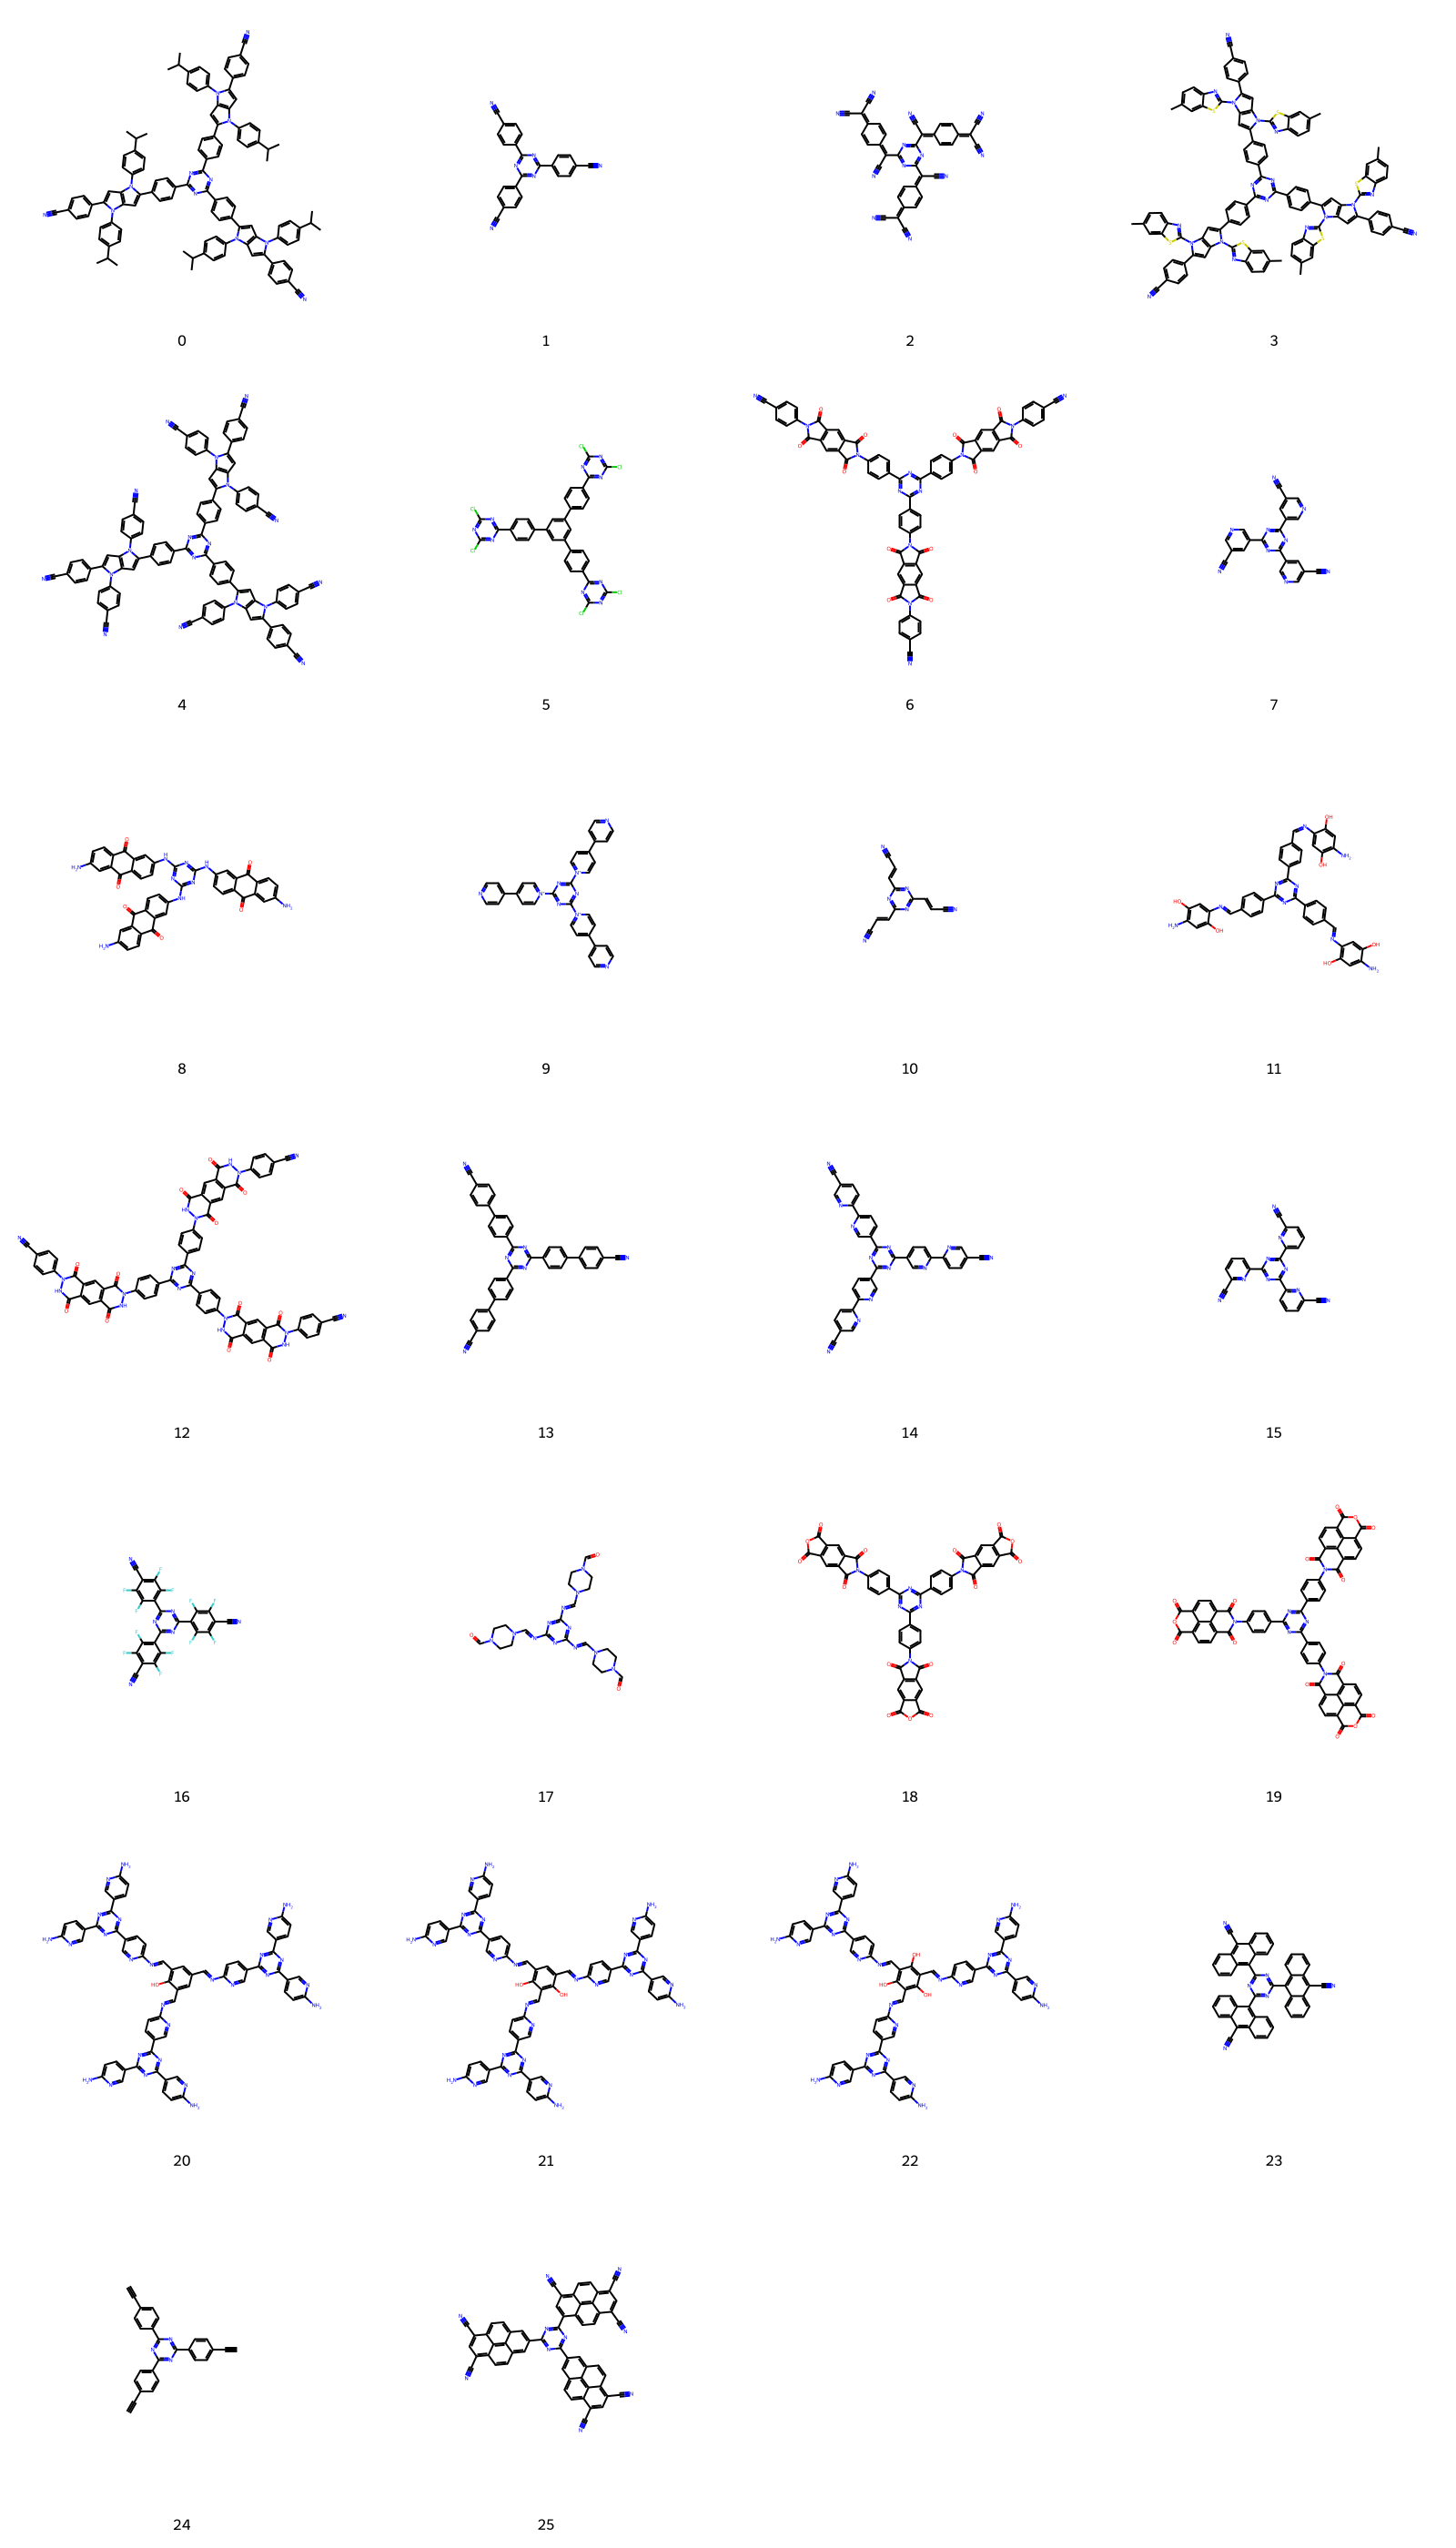

--------------------------------------------
smiles_new_new


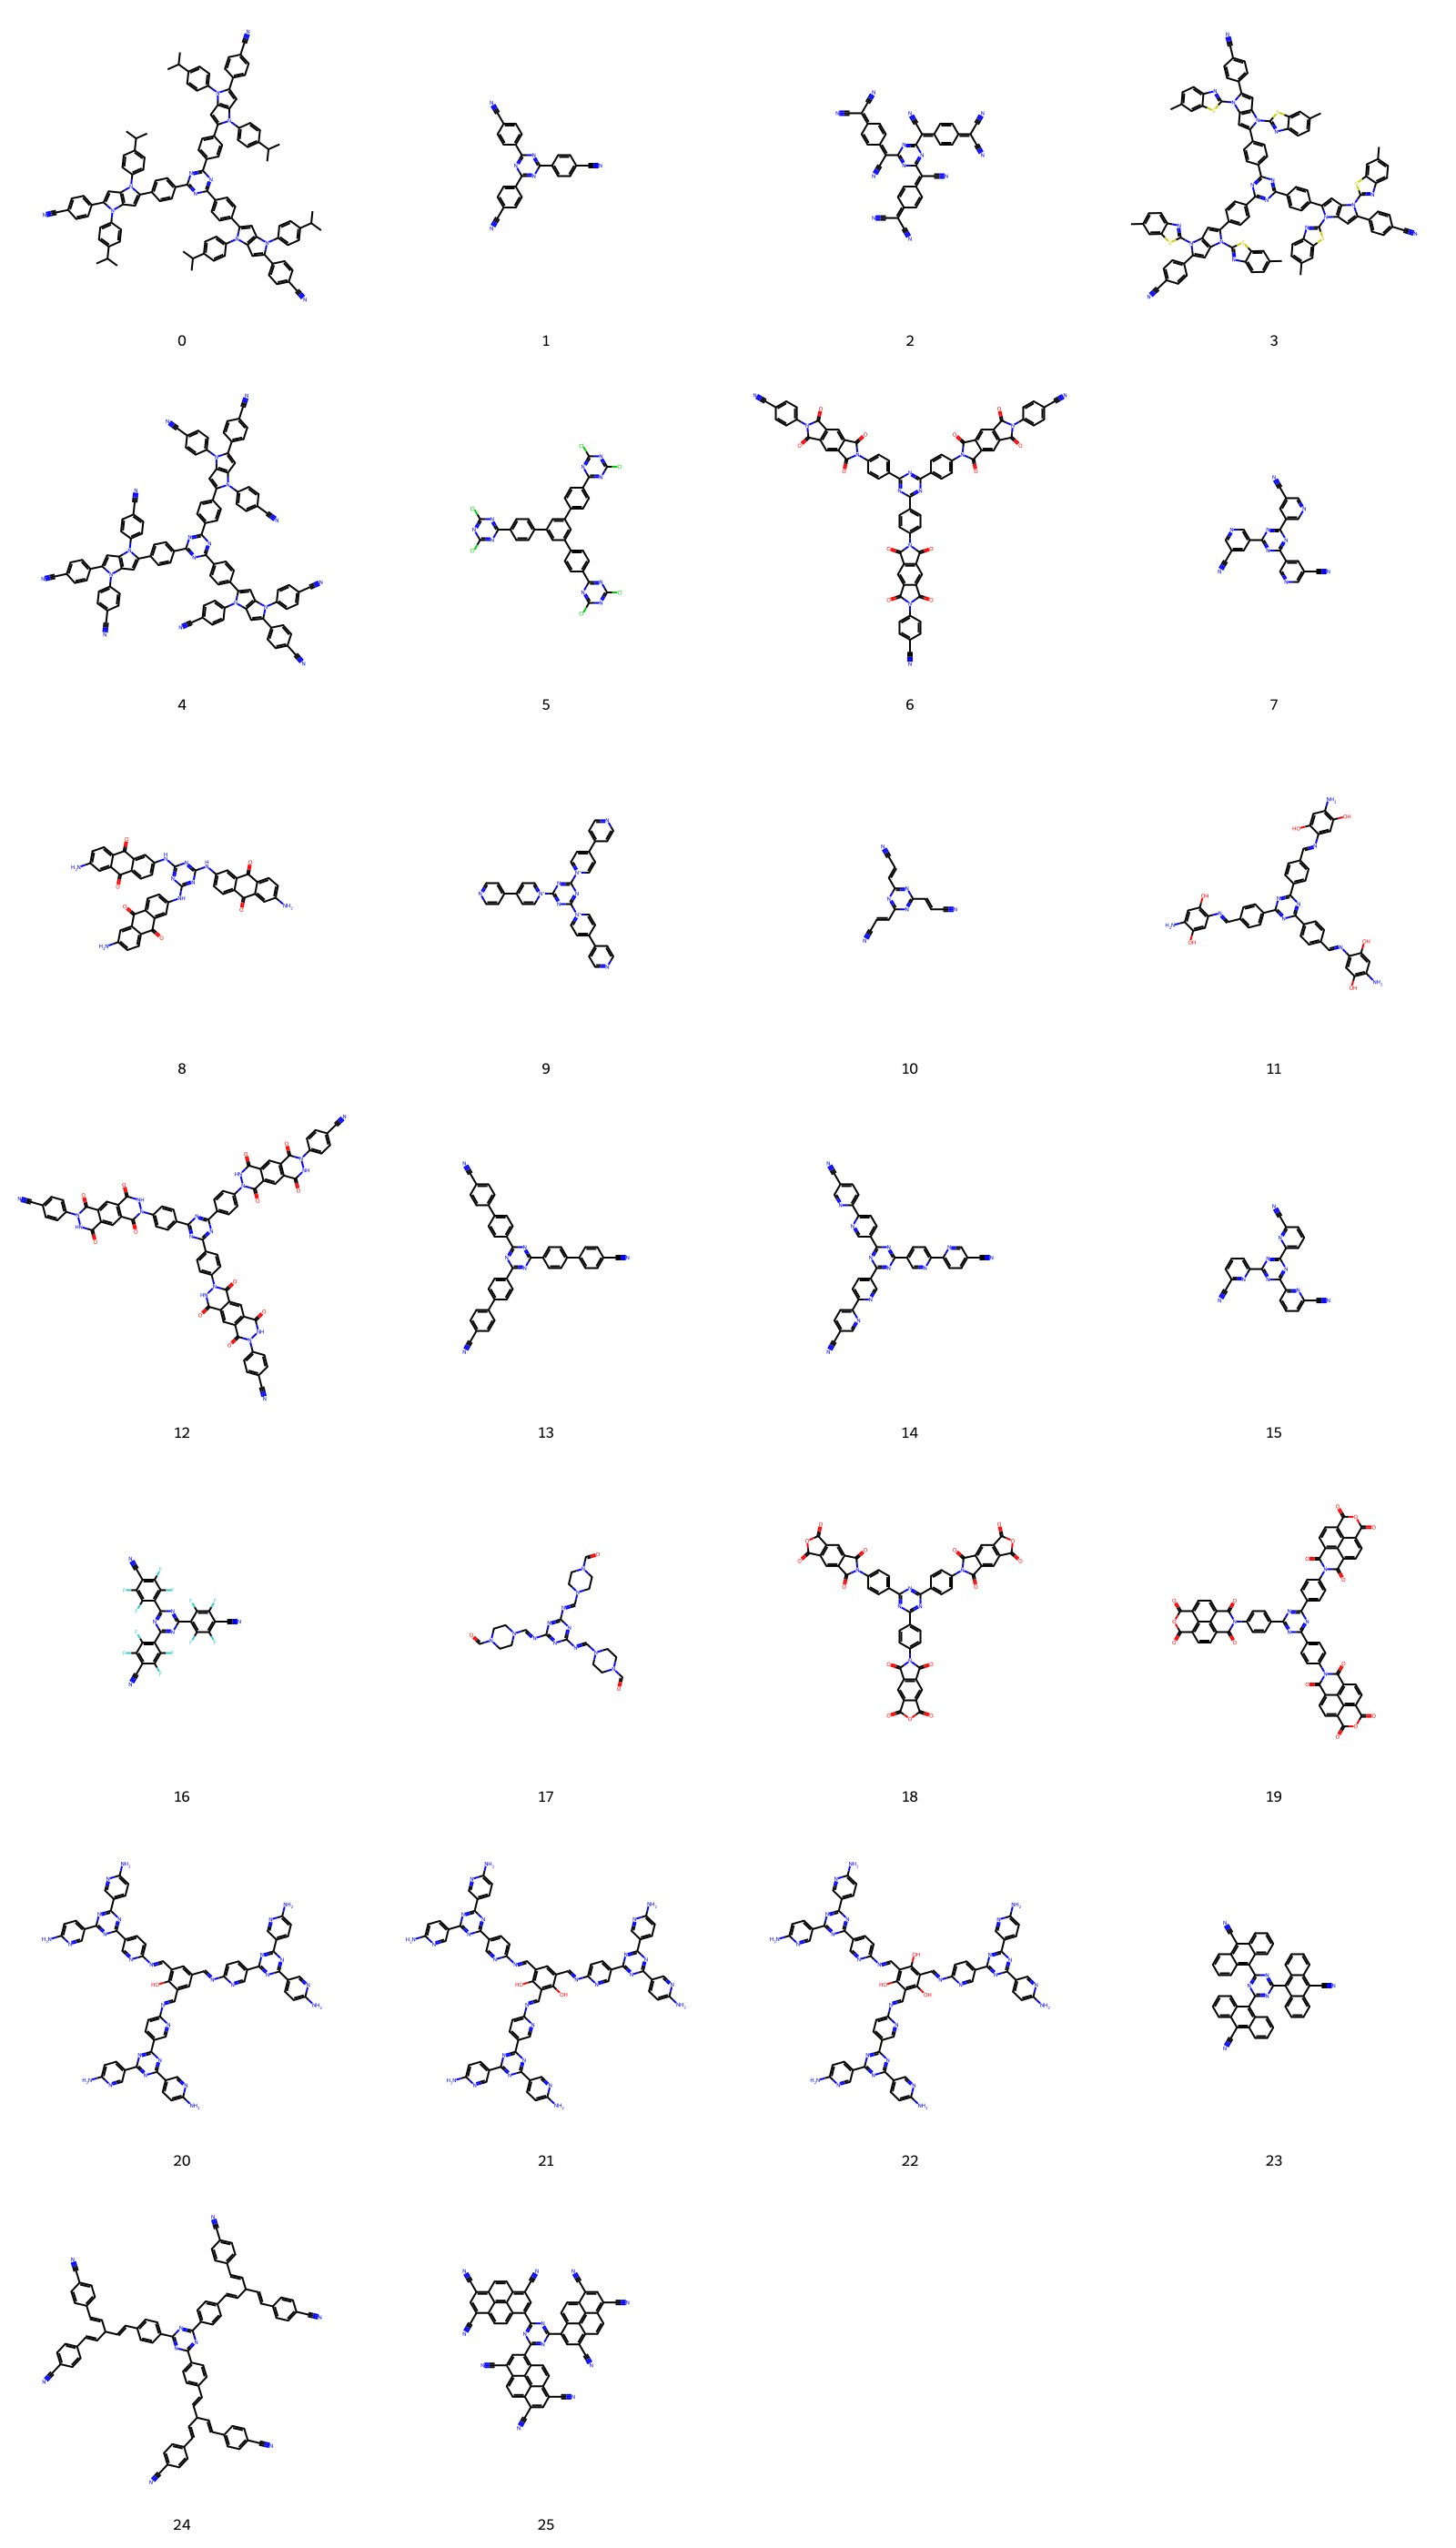

--------------------------------------------


In [85]:
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit import Chem
import pandas as pd
from modules.core.features.utils import canon_smiles



for d in ['smiles_new', 'smiles_new_new']:
    print(d)
    smiles = df_merged[d].tolist()
    ids = df_merged['id'].tolist()
    smiles = [canon_smiles(s) for s in smiles]
    df = pd.DataFrame({'smiles': smiles, 'id': ids})
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
    #df['id'] = list(range(len(df)))
    # for i, s in enumerate(smiles):
    #     print(i, s)
    #     mol = Chem.MolFromSmiles(s)
    #     display(Draw.MolToImage(mol))
    #mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    #display(Draw.MolsToGridImage(mols, molsPerRow=4))
    display(PandasTools.FrameToGridImage(df, legendsCol="id", molsPerRow=4, subImgSize=(400, 400)))
    print('--------------------------------------------')

In [ ]:
df_merged = df_experts1.merge(df_corrected, left_on='smiles', right_on='smiles')
df_merged

In [ ]:
smiles1 = df_experts1['smiles'].tolist()
smiles2 = df_merged['smiles'].tolist()

print(smiles1)

In [ ]:
df_merged = df_merged[['smiles_new', 'capacity_max_y']]
df_merged = df_merged.rename(columns={'smiles_new': 'smiles', 'capacity_max_y': 'capacity_max'})
df_merged

In [ ]:
df_merged.to_csv('../../../data/raw/data_experts1_corrected_matched.csv')

In [ ]:
df_f = pd.read_csv('../../../data/processed_selected_custom_features/data_experts1_corrected_all.csv')
df_merged = df_merged.merge(df_f, left_on='smiles', right_on='smiles')
df_merged

In [ ]:
df_merged.dropna()

In [ ]:
from modules.core.features.preprocessing import canon_smiles
import os

import pandas as pd

from modules.predictor.data.utils import data_preprocessing

# Load data
main_dir = '../../../data'
data_types = {
    'expert': 'data_experts1.csv',
    'expert2': 'data_experts2.csv',
    'expert3': 'data_experts3.csv',
    'zhu': 'data_zhu.csv',
    'saad': 'data_saad.csv',
}
min_smiles = {}
for dtype in data_types:
    print(dtype)
    df = pd.read_csv(os.path.join(main_dir, 'raw', data_types[dtype]))
    df.columns = [x.lower() for x in df.columns]
    df['smiles'] = df['smiles'].apply(canon_smiles)
    df.dropna(subset=['smiles'], inplace=True)
    df.drop_duplicates(subset=['smiles'], inplace=True)
    min_smiles[dtype] = df['smiles'].tolist()

In [ ]:
min_smiles

In [ ]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

In [ ]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        smiles_file = df['smiles'].tolist()
        smiles_now = min_smiles[dtype]
        print(len(smiles_now), len(smiles_file), len([x for x in smiles_now if x in smiles_file]))
        new_smiles = [x for x in smiles_now if x in smiles_file]
        min_smiles[dtype] = new_smiles

In [ ]:
for dtype, dlist in min_smiles.items():
    print(dtype, len(dlist))

In [ ]:
for subdir in [s for s in os.listdir(main_dir) if s not in ['sampling', 'raw', 'symmetries', 'processed_all_custom_features']]:
    print(subdir)
    for dtype, dfile in data_types.items():
        df = pd.read_csv(os.path.join(main_dir, subdir, dfile))
        df.columns = [x.lower() for x in df.columns]
        df['smiles'] = df['smiles'].apply(canon_smiles)
        df.dropna(subset=['smiles'], inplace=True)
        df.drop_duplicates(subset=['smiles'], inplace=True)
        df = df[df['smiles'].isin(min_smiles[dtype])]
        print(dtype, subdir, len(df))
        df.to_csv(os.path.join(main_dir, subdir, dfile), index=False)

In [ ]:

paths = ['../../../data/processed_selected_custom_features/data_experts1.csv',
         '../../../data/fingerprints_layered/data_experts1.csv',
         ]
df = [pd.read_csv(data_path) for data_path in paths]
result = df[0]
for data in df[1:]:
    data = data.drop(columns=['capacity_max'])
    result = pd.merge(result, data, on='smiles', how='inner')
# df = pd.concat(df, axis=1).reset_index(drop=True)
result.columns = result.columns.str.replace(r"[\[\]>]", "", regex=True)
result =result.loc[:, ~result.columns.duplicated()].sort_values(by="smiles").reset_index(drop=True)
result
#print(df)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Plot the distributions of capacity_max

plt.figure(figsize=(12, 8))
for name, df in dfs.items():
    print(name, df['capacity_max'].min(), df['capacity_max'].max())
    sns.histplot(df['capacity_max'], kde=True, label=name, bins=30)

plt.title('Distributions of capacity_max in Selected Datasets')
plt.xlabel('capacity_max')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_paths = {
    'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}

# Read the datasets
dfs = {name: pd.read_csv(path) for name, path in data_paths.items()}

# Combine datasets into a single DataFrame for facet plot
df_combined = pd.concat([df.assign(dataset=name) for name, df in dfs.items()], ignore_index=True)

# Create a violin plot
plt.figure(figsize=(12, 8))
sns.violinplot(x='dataset', y='capacity_max', data=df_combined, cut=0, hue='dataset')
plt.title('Violin Plot of capacity_max in Selected Datasets')
plt.xlabel('Dataset')
plt.ylabel('capacity_max')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=True, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

# Create a facet plot with each dataset on a separate plot
g = sns.FacetGrid(df_combined, col='dataset', col_wrap=3, height=4, sharex=False, sharey=True, hue='dataset')
g.map(sns.histplot, 'capacity_max', kde=False, bins=30)
g.set_titles(col_template="{col_name}")
g.set_axis_labels('capacity_max', 'Frequency')
plt.show()

In [ ]:
df = pd.concat(dfs, ignore_index=True)
df

In [ ]:
num_bins = 6
bins = pd.qcut(df['capacity_max'], q=num_bins, labels=None)
bins

In [ ]:
num_bins = 6
bins = pd.cut(df['capacity_max'], bins=num_bins, labels=False)
bins

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Define the reaction SMARTS
# This reaction connects two nitrile groups via their nitrogen atoms
reaction_smarts = '[C:1]#[N:2].[C:3]#[N:4]>>[C:1]-[N:2]-[N:4]-[C:3]'
reaction = AllChem.ReactionFromSmarts(reaction_smarts)

# Define the reactant molecules with nitrile groups
mol1 = Chem.MolFromSmiles('N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#N)C#N)cc1)nc(C(C#N)=c2ccc(=C(C#N)C#N)cc2)n3)cc4')  # Acetonitrile
mol2 = Chem.MolFromSmiles('N#CC(C#N)=c4ccc(=C(C#N)c3nc(C(C#N)=c1ccc(=C(C#N)C#N)cc1)nc(C(C#N)=c2ccc(=C(C#N)C#N)cc2)n3)cc4')  # Propionitrile

# Run the reaction
products = reaction.RunReactants((mol1, mol2))

for _ in range(0):
    product = products[0][0]
    Chem.SanitizeMol(product)
    products = reaction.RunReactants((product, mol1))
product = products[0][0]
display(Chem.Draw.MolToImage(product))

# # Iterate over possible products and display their SMILES
# for product_set in products:
#     for product in product_set:
#         Chem.SanitizeMol(product)
#         print(Chem.MolToSmiles(product))
#         display(Chem.Draw.MolToImage(product))

expert1_corrected
0 CC(C)c1ccc(-n2c(-c3ccc(C#N)cc3)cc3c2cc(-c2ccc(-c4nc(-c5ccc(-c6cc7c(cc(-c8ccc(C#N)cc8)n7-c7ccc(C(C)C)cc7)n6-c6ccc(C(C)C)cc6)cc5)nc(-c5ccc(-c6cc7c(cc(-c8ccc(C#N)cc8)n7-c7ccc(C(C)C)cc7)n6-c6ccc(C(C)C)cc6)cc5)n4)cc2)n3-c2ccc(C(C)C)cc2)cc1


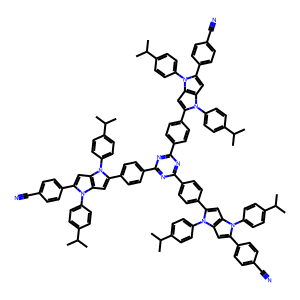

1 N#Cc1ccc(-c2nc(-c3ccc(C#N)cc3)nc(-c3ccc(C#N)cc3)n2)cc1


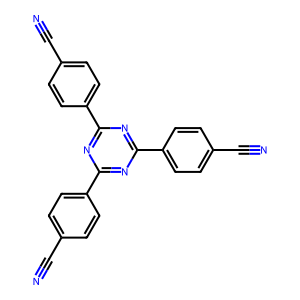

2 N#CC(C#N)=c1ccc(=C(C#N)c2nc(C(C#N)=c3ccc(=C(C#N)C#N)cc3)nc(C(C#N)=c3ccc(=C(C#N)C#N)cc3)n2)cc1


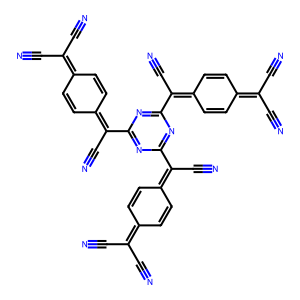

3 Cc1ccc2nc(-n3c(-c4ccc(C#N)cc4)cc4c3cc(-c3ccc(-c5nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8nc9ccc(C)cc9s8)n7-c7nc8ccc(C)cc8s7)cc6)nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8nc9ccc(C)cc9s8)n7-c7nc8ccc(C)cc8s7)cc6)n5)cc3)n4-c3nc4ccc(C)cc4s3)sc2c1


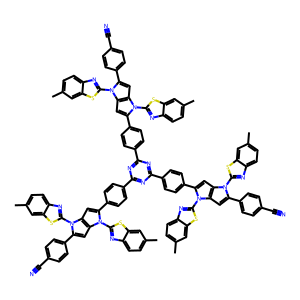

4 N#Cc1ccc(-c2cc3c(cc(-c4ccc(-c5nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8ccc(C#N)cc8)n7-c7ccc(C#N)cc7)cc6)nc(-c6ccc(-c7cc8c(cc(-c9ccc(C#N)cc9)n8-c8ccc(C#N)cc8)n7-c7ccc(C#N)cc7)cc6)n5)cc4)n3-c3ccc(C#N)cc3)n2-c2ccc(C#N)cc2)cc1


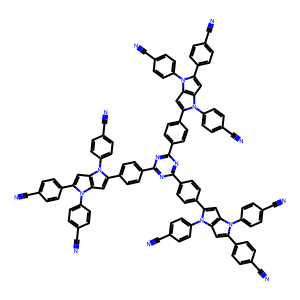

5 Clc1nc(Cl)nc(-c2ccc(-c3cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)cc(-c4ccc(-c5nc(Cl)nc(Cl)n5)cc4)c3)cc2)n1


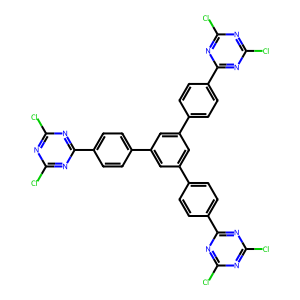

6 N#Cc1ccc(-n2c(=O)c3cc4c(=O)n(-c5ccc(-c6nc(-c7ccc(-n8c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)nc(-c7ccc(-n8c(=O)c9cc%10c(=O)n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)n6)cc5)c(=O)c4cc3c2=O)cc1


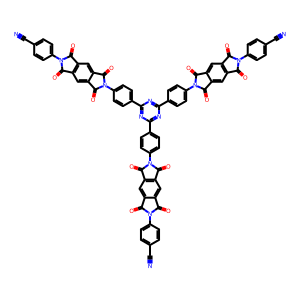

7 N#Cc1cncc(-c2nc(-c3cncc(C#N)c3)nc(-c3cncc(C#N)c3)n2)c1


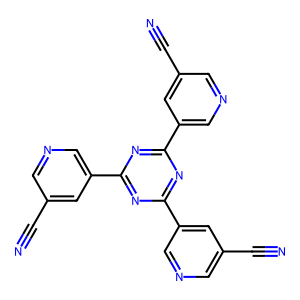

8 Nc1ccc2c(c1)C(=O)c1ccc(Nc3nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)nc(Nc4ccc5c(c4)C(=O)c4ccc(N)cc4C5=O)n3)cc1C2=O


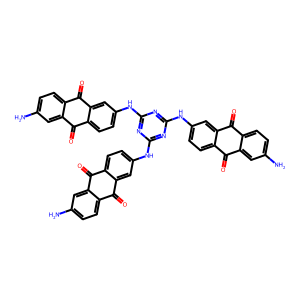

9 c1cc(-c2cc[n+](-c3nc(-[n+]4ccc(-c5ccncc5)cc4)nc(-[n+]4ccc(-c5ccncc5)cc4)n3)cc2)ccn1


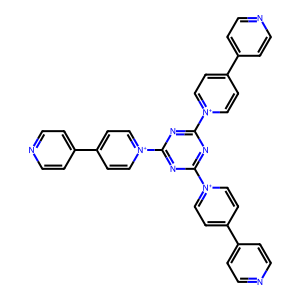

10 N#C/C=C/c1nc(/C=C/C#N)nc(/C=C/C#N)n1


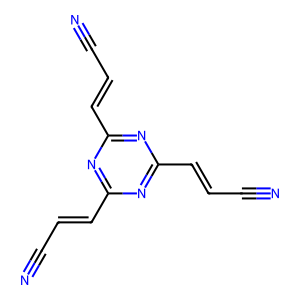

11 Nc1cc(O)c(N=Cc2ccc(-c3nc(-c4ccc(/C=N\c5cc(O)c(N)cc5O)cc4)nc(-c4ccc(/C=N/c5cc(O)c(N)cc5O)cc4)n3)cc2)cc1O


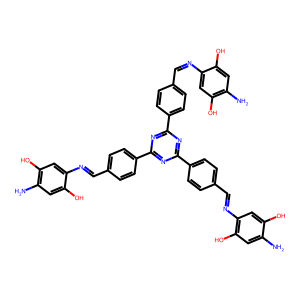

12 N#Cc1ccc(-n2[nH]c(=O)c3cc4c(=O)[nH]n(-c5ccc(-c6nc(-c7ccc(-n8[nH]c(=O)c9cc%10c(=O)[nH]n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)nc(-c7ccc(-n8[nH]c(=O)c9cc%10c(=O)[nH]n(-c%11ccc(C#N)cc%11)c(=O)c%10cc9c8=O)cc7)n6)cc5)c(=O)c4cc3c2=O)cc1


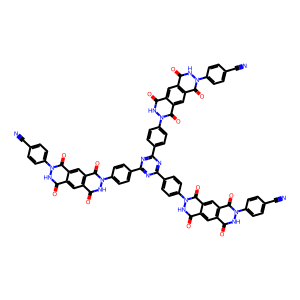

13 N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cc5)cc4)nc(-c4ccc(-c5ccc(C#N)cc5)cc4)n3)cc2)cc1


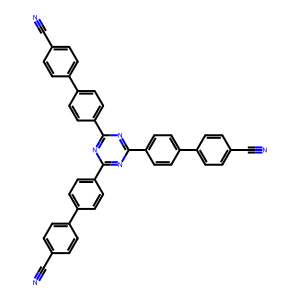

14 N#Cc1ccc(-c2ccc(-c3nc(-c4ccc(-c5ccc(C#N)cn5)nc4)nc(-c4ccc(-c5ccc(C#N)cn5)nc4)n3)cn2)nc1


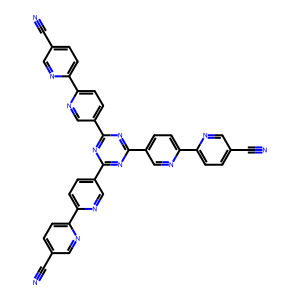

15 N#Cc1cccc(-c2nc(-c3cccc(C#N)n3)nc(-c3cccc(C#N)n3)n2)n1


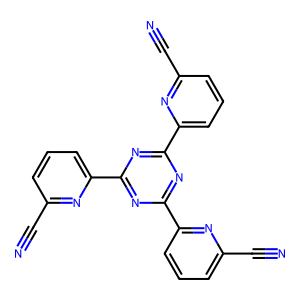

16 N#Cc1c(F)c(F)c(-c2nc(-c3c(F)c(F)c(C#N)c(F)c3F)nc(-c3c(F)c(F)c(C#N)c(F)c3F)n2)c(F)c1F


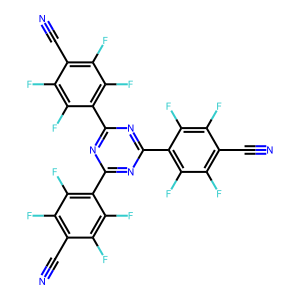

17 O=CN1CCN(C=Nc2nc(/N=C/N3CCN(C=O)CC3)nc(/N=C/N3CCN(C=O)CC3)n2)CC1


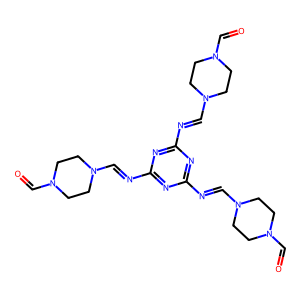

18 O=c1oc(=O)c2cc3c(=O)n(-c4ccc(-c5nc(-c6ccc(-n7c(=O)c8cc9c(=O)oc(=O)c9cc8c7=O)cc6)nc(-c6ccc(-n7c(=O)c8cc9c(=O)oc(=O)c9cc8c7=O)cc6)n5)cc4)c(=O)c3cc12


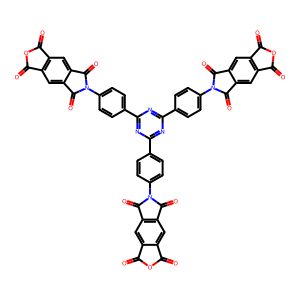

19 O=C1OC(=O)c2ccc3c4c(ccc1c24)C(=O)N(c1ccc(-c2nc(-c4ccc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)OC7=O)cc4)nc(-c4ccc(N5C(=O)c6ccc7c8c(ccc(c68)C5=O)C(=O)OC7=O)cc4)n2)cc1)C3=O


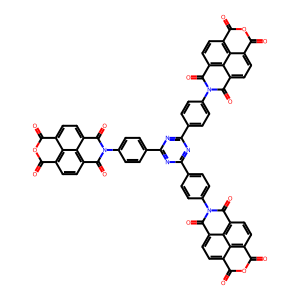

20 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4cc(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4)nc3)n2)cn1


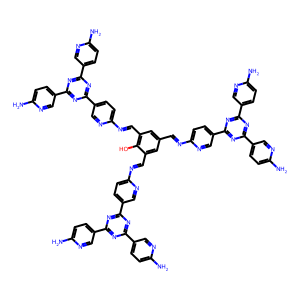

21 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4cc(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4O)nc3)n2)cn1


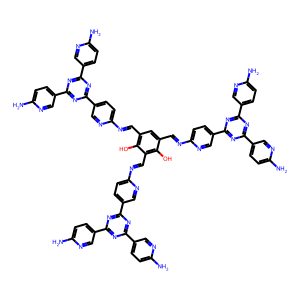

22 Nc1ccc(-c2nc(-c3ccc(N)nc3)nc(-c3ccc(/N=C/c4c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c(O)c(/C=N/c5ccc(-c6nc(-c7ccc(N)nc7)nc(-c7ccc(N)nc7)n6)cn5)c4O)nc3)n2)cn1


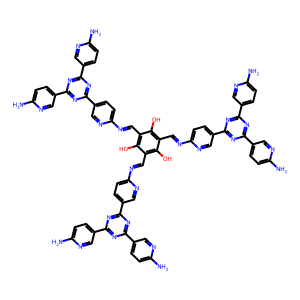

23 N#Cc1c2ccccc2c(-c2nc(-c3c4ccccc4c(C#N)c4ccccc34)nc(-c3c4ccccc4c(C#N)c4ccccc34)n2)c2ccccc12


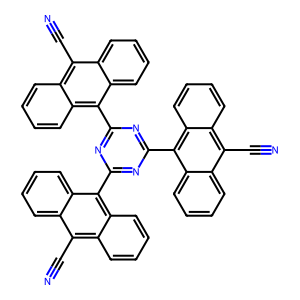

24 C#Cc1ccc(-c2nc(-c3ccc(C#C)cc3)nc(-c3ccc(C#C)cc3)n2)cc1


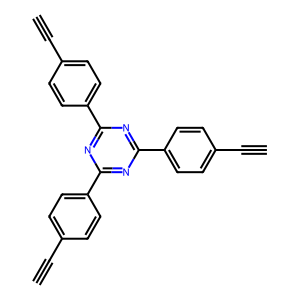

25 N#Cc1cc(C#N)c2ccc3cc(-c4nc(-c5cc6ccc7c(C#N)cc(C#N)c8ccc(c5)c6c78)nc(-c5cc(C#N)c6ccc7c(C#N)cc(C#N)c8ccc5c6c78)n4)cc4ccc1c2c43


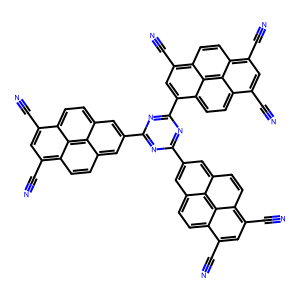

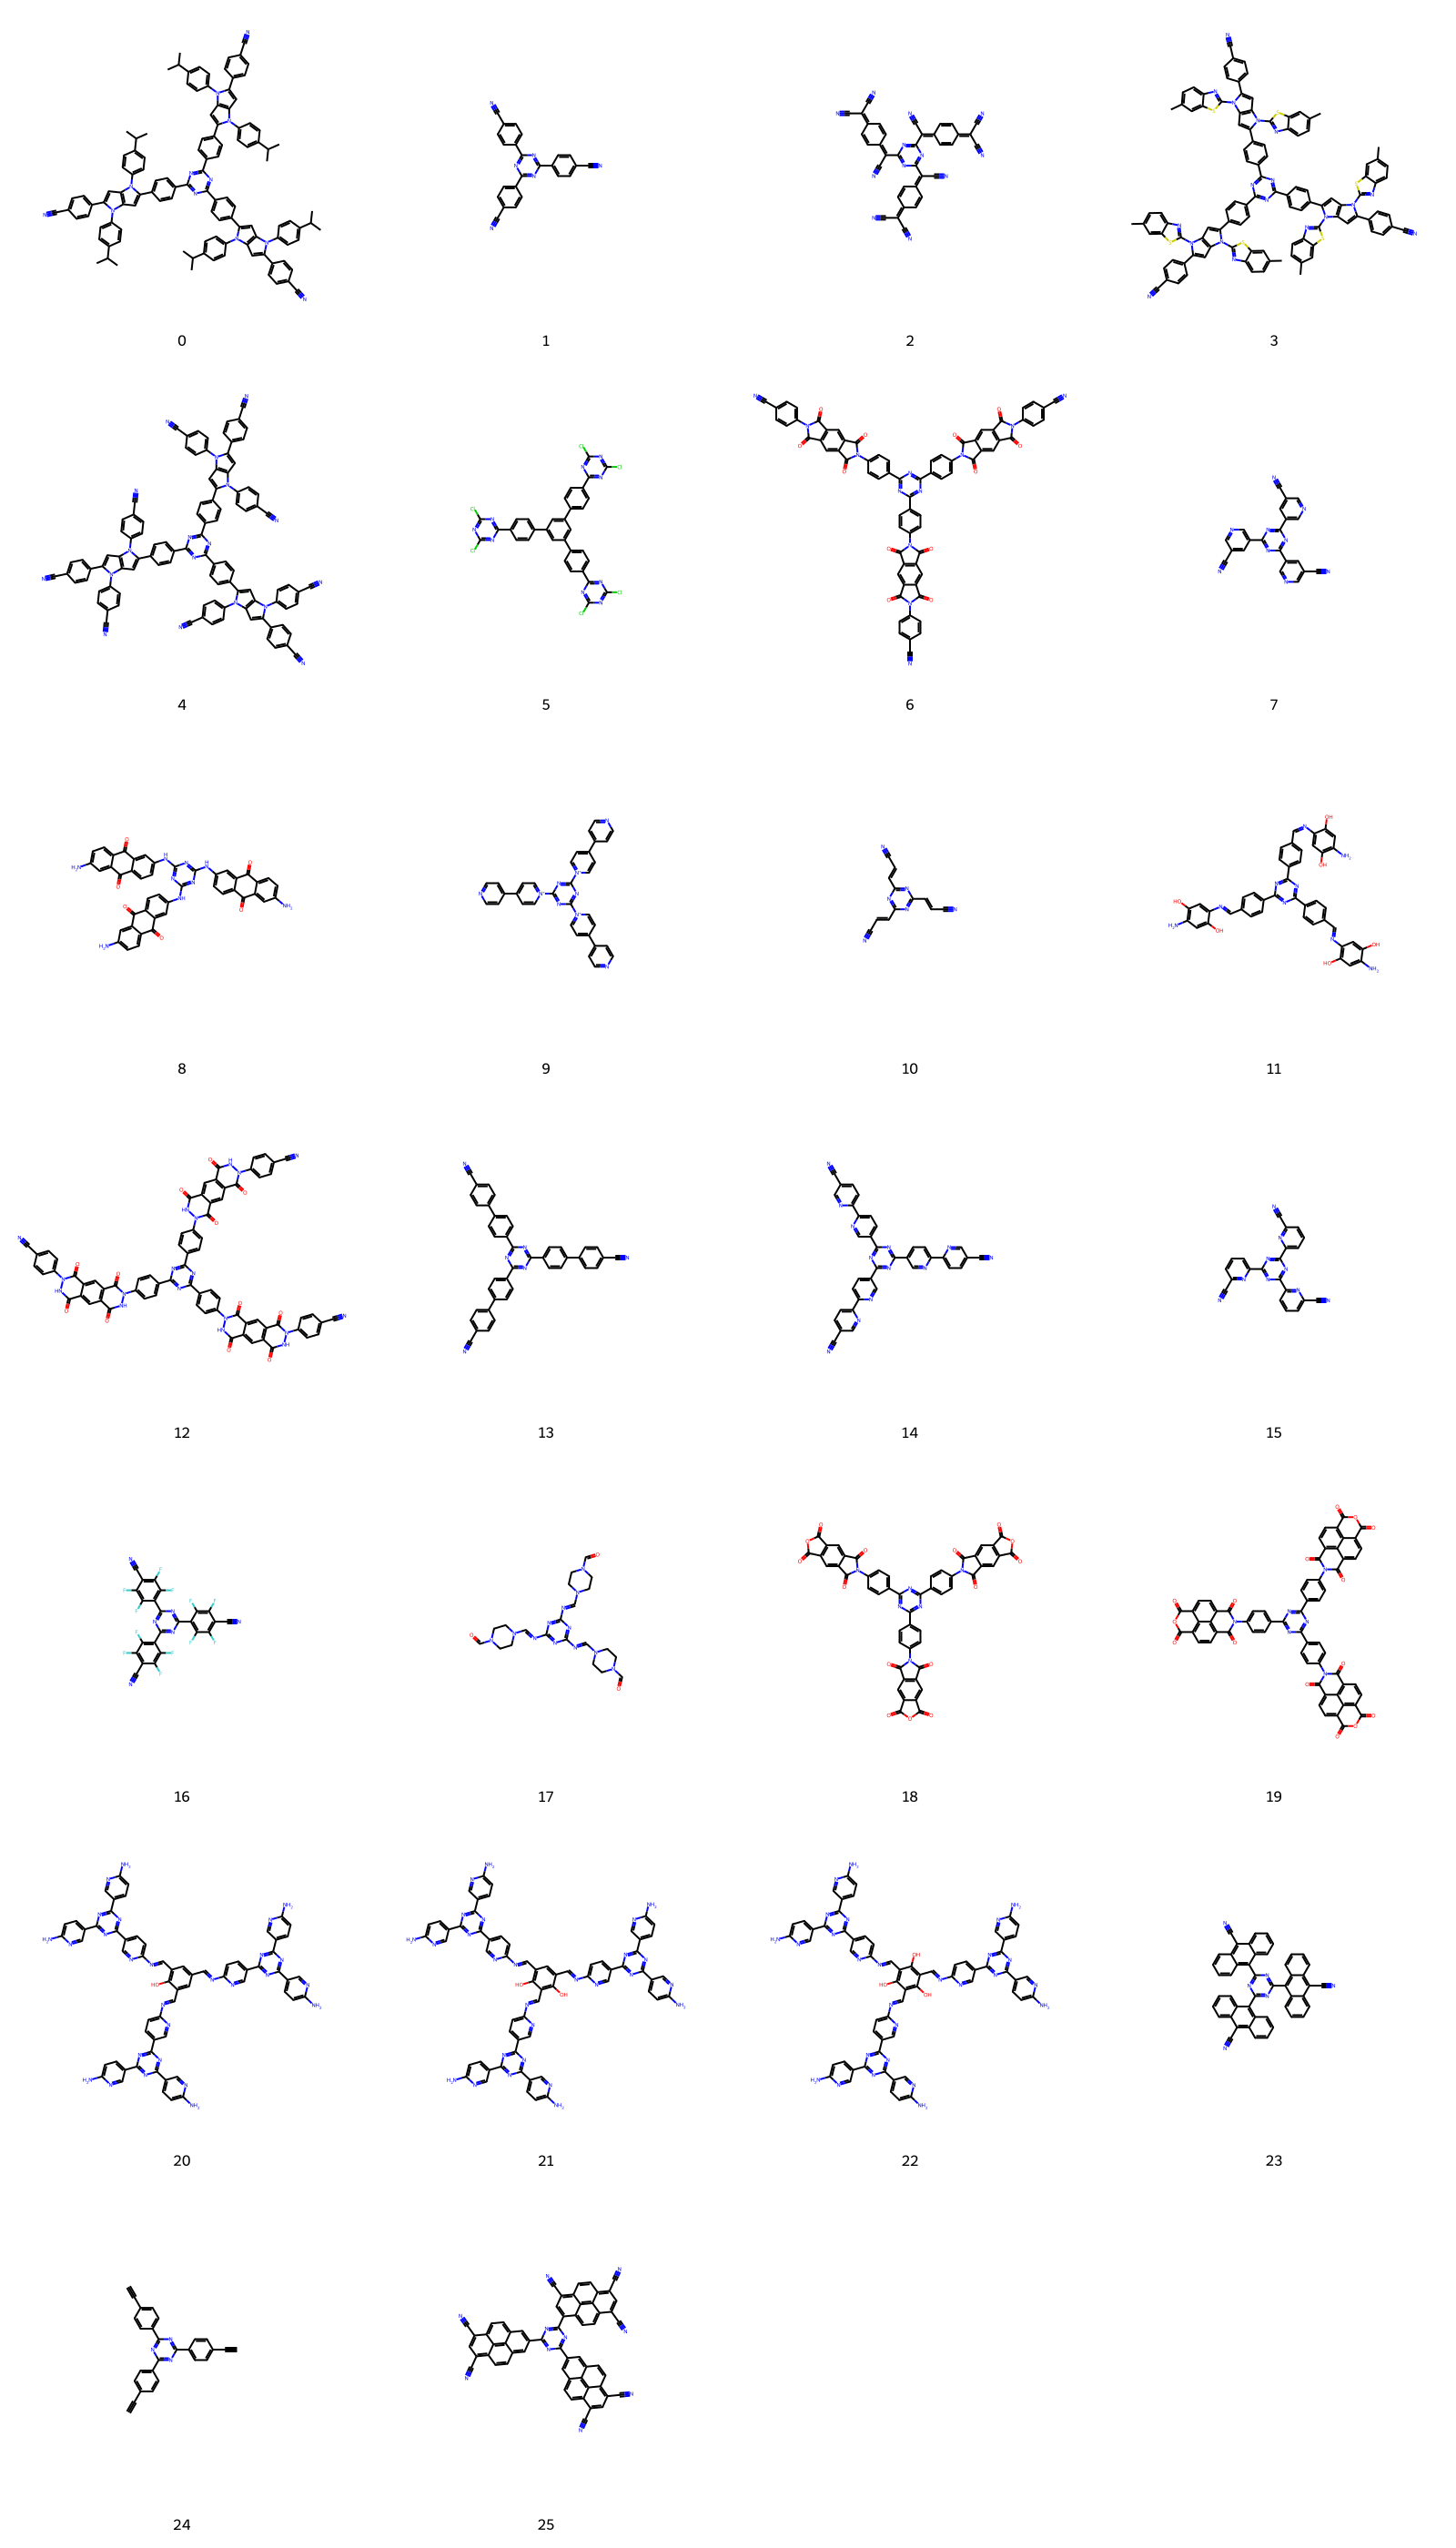

--------------------------------------------


In [29]:
import numpy as np
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit import Chem
import pandas as pd
from modules.core.features.utils import canon_smiles


data_paths = {
    # 'expert1': '../../../data/processed_selected_custom_features/data_experts1.csv',
    'expert1_corrected': '../../../data/raw/data_experts1_corrected.csv',
    # 'expert2': '../../../data/processed_selected_custom_features/data_experts2.csv',
    # 'saad': '../../../data/processed_selected_custom_features/data_saad.csv',
    # 'zhu': '../../../data/processed_selected_custom_features/data_zhu.csv',
    # 'expert3': '../../../data/processed_selected_custom_features/data_experts3.csv'
}
for data_name, df_path in data_paths.items():
    df_small = pd.read_csv(df_path)
    print(data_name)

    if data_name == 'expert1_corrected':
        smiles = df_small['smiles'].drop_duplicates().tolist()
    else:
        smiles = df_small['smiles'].drop_duplicates().tolist()
    smiles = [canon_smiles(s) for s in smiles]
    df = pd.DataFrame({'smiles': smiles})
    PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')
    df['id'] = list(range(len(df)))
    for i, s in enumerate(smiles):
        print(i, s)
        mol = Chem.MolFromSmiles(s)
        display(Draw.MolToImage(mol))
    #mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    #display(Draw.MolsToGridImage(mols, molsPerRow=4))
    display(PandasTools.FrameToGridImage(df, legendsCol="id", molsPerRow=4, subImgSize=(400, 400)))
    print('--------------------------------------------')

In [ ]:
import numpy as np
from rdkit.Chem import Draw
from rdkit import Chem

df['bins'] = bins
unique_bins = sorted(np.unique(bins.tolist()))
for b in unique_bins:
    df_small = df[df['bins'] == b]
    print(b, df_small['capacity_max'].min(), df_small['capacity_max'].max(), len(df_small))
    smiles = df_small['smiles'].tolist()
    mols = [Chem.MolFromSmiles(smi) for smi in smiles]
    display(Draw.MolsToGridImage(mols, molsPerRow=4))
    plt.show()

In [ ]:
#point-biserial

import pandas as pd
import numpy as np
from scipy import stats

custom_features = '../../../data/processed_selected_custom_features/data_experts1.csv'
maccs_features = '../../../data/fingerprints_maccs/data_experts1.csv'
df_custom = pd.read_csv(custom_features)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.read_csv(maccs_features)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)

correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation

correlation_matrix.T


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
data_names = ['experts1', 'experts2', ]#'experts3', 'saad', 'zhu']
custom_features = [f'../../../data/processed_selected_custom_features/data_{dname}.csv' for dname in data_names]
maccs_features = [f'../../../data/fingerprints_maccs/data_{dname}.csv' for dname in data_names]
df_custom = pd.concat([pd.read_csv(cf) for cf in custom_features], ignore_index=True)
df_custom.sort_values(by='smiles', inplace=True)
df_custom = df_custom[['flatness', 'ps']]
df_maccs = pd.concat([pd.read_csv(cf) for cf in maccs_features], ignore_index=True)
df_maccs.sort_values(by='smiles', inplace=True)
df_maccs.drop(columns=['capacity_max', 'smiles'], inplace=True)
df_maccs.describe()
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.pointbiserialr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

In [ ]:
correlation_matrix = pd.DataFrame(index=df_custom.columns, columns=df_maccs.columns)
for i, col1 in enumerate(df_custom.columns):
    for j, col2 in enumerate(df_maccs.columns):
        correlation_matrix.iloc[i, j] = stats.spearmanr(df_maccs[col2], df_custom[col1]).correlation
#
correlation_matrix.T

In [ ]:
f_to_remove = []
for i, col in enumerate(df_maccs.columns):
    if df_maccs[col].max() == df_maccs[col].min():
        f_to_remove.append(col)
f_to_remove

In [ ]:
new_dir = '../../../data/selected_maccs'
import os
os.makedirs(new_dir, exist_ok=True)
for data_name in data_names:
    print(data_name)
    df = pd.read_csv(f'../../../data/fingerprints_maccs/data_{data_name}.csv')
    print(df.head())
    df.drop(columns=f_to_remove, inplace=True)
    df.to_csv(f'{new_dir}/data_{data_name}.csv', index=False)